# TikTok Channel Analytics — Portfolio Analysis
**Author:** Andrew Espinosa  
**Dataset:** Daily TikTok performance metrics (364 days)  
**Tools:** Python, pandas, matplotlib, seaborn, scipy

---

This notebook demonstrates an end-to-end data analytics workflow:
1. Data ingestion & cleaning
2. Validation & quality checks
3. KPI / performance indicator calculation
4. Trend analysis with rolling averages
5. Correlation analysis
6. Day-of-week behavioral patterns
7. Actionable recommendations

## 1. Setup & Data Ingestion

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'sans-serif'
})

ACCENT = '#4361EE'
SECONDARY = '#F72585'
TERTIARY = '#7209B7'

# Load data
df_raw = pd.read_csv('Mar25-56.csv')
print(f'Loaded {len(df_raw)} rows x {len(df_raw.columns)} columns')
df_raw.head()

Loaded 365 rows x 6 columns


,Date,Video Views,Profile Views,Likes,Comments,Shares
0,March 31,935,3,100,37,3
1,April 1,704,1,81,16,4
2,April 2,965,5,113,42,7
3,April 3,1007,4,103,35,6
4,April 4,1003,7,108,29,5


## 2. Data Cleaning & Validation

In [6]:
df = df_raw.copy()

# --- Column normalization ---
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns:', df.columns.tolist())

# --- Date parsing ---
# Dates lack a year; infer year from sequence (dataset spans Mar 2025 - Mar 2026)
def parse_date_with_year(date_str, start_year=2025):
    """Assign year by tracking month rollovers."""
    return pd.to_datetime(f"{date_str} {start_year}", format='%B %d %Y')

# Parse first pass assuming all 2025
df['date'] = df['date'].apply(lambda x: pd.to_datetime(f"{x} 2025", format='%B %d %Y'))

# Fix year rollover: any date that goes backwards in time => bump to 2026
for i in range(1, len(df)):
    if df.loc[i, 'date'] < df.loc[i-1, 'date']:
        df.loc[i:, 'date'] = df.loc[i:, 'date'].apply(
            lambda d: d.replace(year=d.year + 1)
        )
        break

df = df.sort_values('date').reset_index(drop=True)
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

# --- Null / missing check ---
print('\nMissing values per column:')
print(df.isnull().sum())

Columns: ['date', 'video_views', 'profile_views', 'likes', 'comments', 'shares']
Date range: 2025-03-31 to 2026-03-30

Missing values per column:
date             0
video_views      0
profile_views    0
likes            0
comments         0
shares           0
dtype: int64


In [7]:
# --- Anomaly: Negative values ---
# TikTok exports Comments as net delta (new comments minus removed/hidden).
# Negative values are valid data — they represent days where comment removals
# exceeded new comments. We will flag them but retain for analysis.

numeric_cols = ['video_views', 'profile_views', 'likes', 'comments', 'shares']

print('Negative value counts per column:')
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count:
        print(f'  {col}: {neg_count} rows  (min={df[col].min()})')

# Flag negative comment days for transparency
df['comments_flag'] = df['comments'] < 0

# For engagement rate, floor comments at 0 (can't have negative interaction volume)
df['comments_adj'] = df['comments'].clip(lower=0)

print('\nData validation complete. Dataset is clean and ready for analysis.')

Negative value counts per column:
  comments: 120 rows  (min=-37)

Data validation complete. Dataset is clean and ready for analysis.


## 3. Key Performance Indicators (KPIs)

In [8]:
# --- Derived metrics ---
df['engagement_rate'] = (df['likes'] + df['comments_adj'] + df['shares']) / df['video_views']
df['like_rate']       = df['likes']    / df['video_views']
df['comment_rate']    = df['comments_adj'] / df['video_views']
df['share_rate']      = df['shares']   / df['video_views']
df['month']           = df['date'].dt.to_period('M')
df['day_of_week']     = df['date'].dt.day_name()
df['week']            = df['date'].dt.isocalendar().week.astype(int)

# --- Summary KPI table ---
kpis = {
    'Total Video Views':        f"{df['video_views'].sum():,}",
    'Total Likes':              f"{df['likes'].sum():,}",
    'Total Shares':             f"{df['shares'].sum():,}",
    'Avg Daily Views':          f"{df['video_views'].mean():,.0f}",
    'Peak Daily Views':         f"{df['video_views'].max():,}  ({df.loc[df['video_views'].idxmax(), 'date'].date()})",
    'Avg Engagement Rate':      f"{df['engagement_rate'].mean():.2%}",
    'Peak Engagement Rate':     f"{df['engagement_rate'].max():.2%}  ({df.loc[df['engagement_rate'].idxmax(), 'date'].date()})",
    'Avg Like Rate':            f"{df['like_rate'].mean():.2%}",
    'Avg Share Rate':           f"{df['share_rate'].mean():.2%}",
    'Days with Negative Comments': str((df['comments'] < 0).sum()),
}

kpi_df = pd.DataFrame(list(kpis.items()), columns=['KPI', 'Value'])
kpi_df.style.set_properties(**{'text-align': 'left'}).hide(axis='index')

KPI,Value
Total Video Views,"258,552"
Total Likes,"29,764"
Total Shares,"1,619"
Avg Daily Views,708
Peak Daily Views,"5,300 (2025-09-13)"
Avg Engagement Rate,11.86%
Peak Engagement Rate,29.39% (2025-07-25)
Avg Like Rate,10.81%
Avg Share Rate,0.58%
Days with Negative Comments,120


## 4. Trend Analysis — Rolling Averages

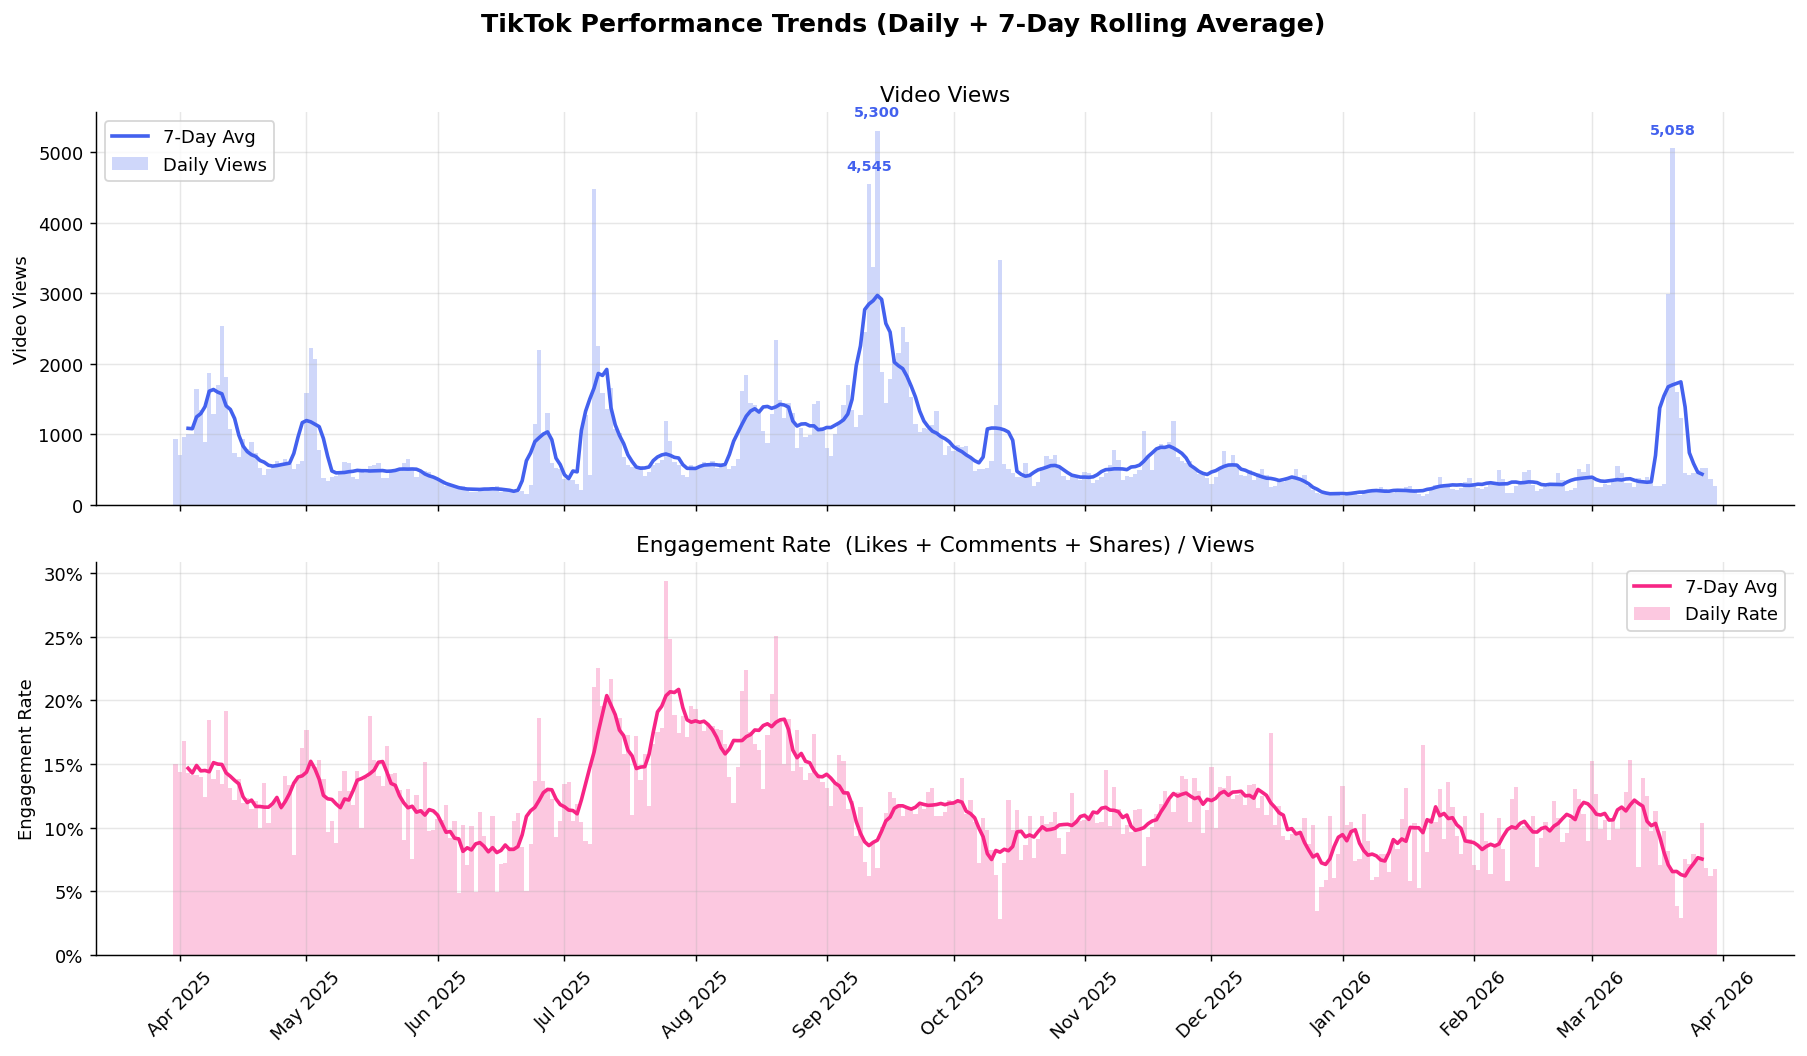

In [9]:
df['views_7d_avg']      = df['video_views'].rolling(7, center=True).mean()
df['engagement_7d_avg'] = df['engagement_rate'].rolling(7, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('TikTok Performance Trends (Daily + 7-Day Rolling Average)', fontsize=14, fontweight='bold', y=1.01)

# --- Panel 1: Video Views ---
ax1 = axes[0]
ax1.bar(df['date'], df['video_views'], color=ACCENT, alpha=0.25, width=1, label='Daily Views')
ax1.plot(df['date'], df['views_7d_avg'], color=ACCENT, linewidth=2, label='7-Day Avg')
ax1.set_ylabel('Video Views')
ax1.set_title('Video Views')
ax1.legend()

# Annotate top spikes
top5 = df.nlargest(3, 'video_views')
for _, row in top5.iterrows():
    ax1.annotate(f"{row['video_views']:,}",
                 xy=(row['date'], row['video_views']),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8, color=ACCENT, fontweight='bold')

# --- Panel 2: Engagement Rate ---
ax2 = axes[1]
ax2.bar(df['date'], df['engagement_rate'], color=SECONDARY, alpha=0.25, width=1, label='Daily Rate')
ax2.plot(df['date'], df['engagement_7d_avg'], color=SECONDARY, linewidth=2, label='7-Day Avg')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.set_ylabel('Engagement Rate')
ax2.set_title('Engagement Rate  (Likes + Comments + Shares) / Views')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('trend_analysis.png', bbox_inches='tight')
plt.show()

## 5. Monthly Performance Summary

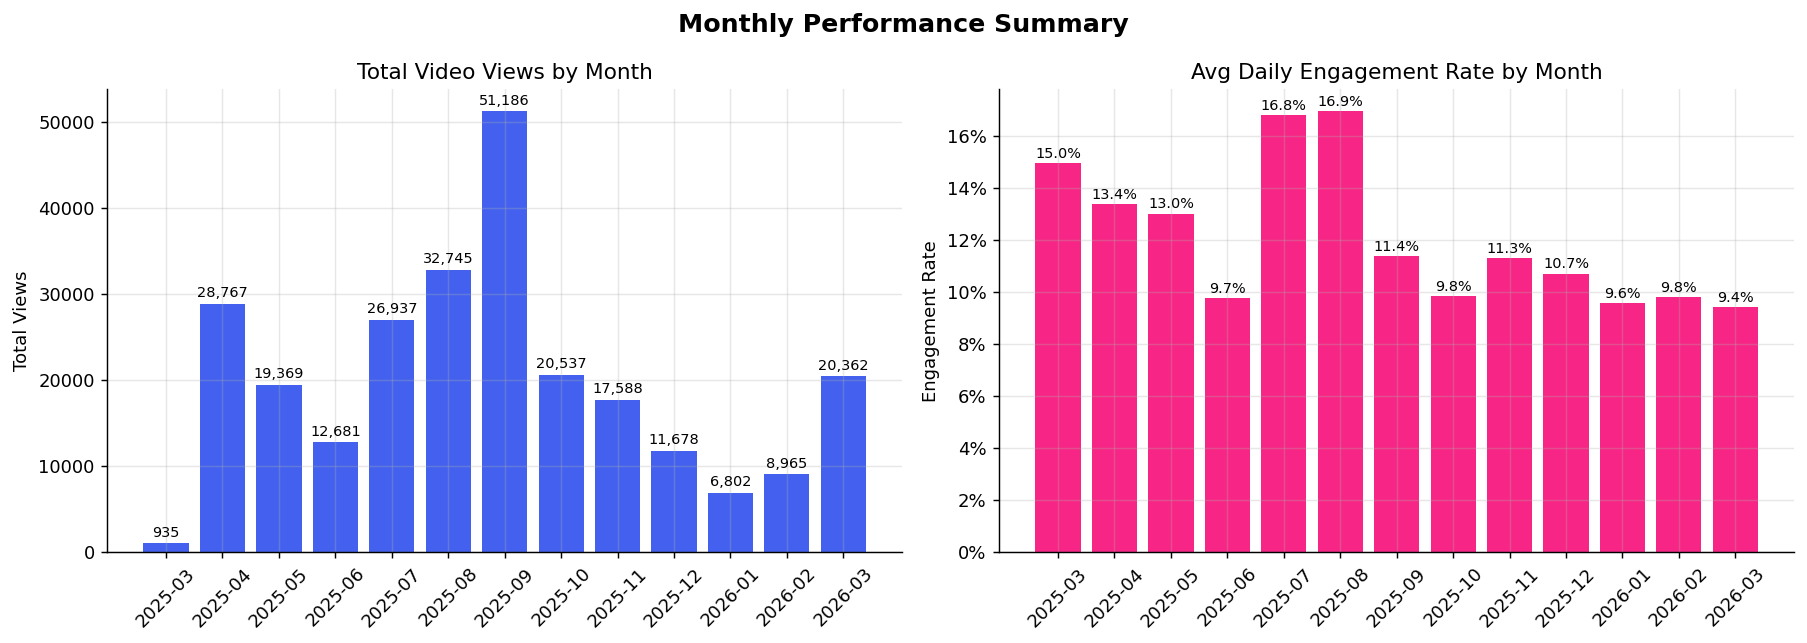

Month,Total Views,Avg Daily Views,Avg Engagement Rate,Peak Views
2025-03,935,935,14.97%,935
2025-04,"28,767",959,13.37%,"2,536"
2025-05,"19,369",625,13.01%,"2,222"
2025-06,"12,681",423,9.75%,"2,191"
2025-07,"26,937",869,16.80%,"4,481"
2025-08,"32,745","1,056",16.95%,"2,345"
2025-09,"51,186","1,706",11.36%,"5,300"
2025-10,"20,537",662,9.84%,"3,470"
2025-11,"17,588",586,11.31%,"1,195"
2025-12,"11,678",377,10.70%,761


In [10]:
monthly = df.groupby('month').agg(
    total_views   = ('video_views',    'sum'),
    avg_views     = ('video_views',    'mean'),
    total_likes   = ('likes',          'sum'),
    total_shares  = ('shares',         'sum'),
    avg_engagement= ('engagement_rate','mean'),
    peak_views    = ('video_views',    'max')
).reset_index()

monthly['month_str'] = monthly['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly Performance Summary', fontsize=14, fontweight='bold')

# Total views per month
bars = axes[0].bar(monthly['month_str'], monthly['total_views'], color=ACCENT)
axes[0].set_title('Total Video Views by Month')
axes[0].set_ylabel('Total Views')
axes[0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, monthly['total_views']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=8)

# Avg engagement rate per month
bars2 = axes[1].bar(monthly['month_str'], monthly['avg_engagement'], color=SECONDARY)
axes[1].set_title('Avg Daily Engagement Rate by Month')
axes[1].set_ylabel('Engagement Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].tick_params(axis='x', rotation=45)
for bar, val in zip(bars2, monthly['avg_engagement']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.1%}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('monthly_summary.png', bbox_inches='tight')
plt.show()

# Display table
display_monthly = monthly[['month_str','total_views','avg_views','avg_engagement','peak_views']].copy()
display_monthly.columns = ['Month','Total Views','Avg Daily Views','Avg Engagement Rate','Peak Views']
display_monthly['Avg Daily Views'] = display_monthly['Avg Daily Views'].map('{:,.0f}'.format)
display_monthly['Total Views']     = display_monthly['Total Views'].map('{:,}'.format)
display_monthly['Peak Views']      = display_monthly['Peak Views'].map('{:,}'.format)
display_monthly['Avg Engagement Rate'] = display_monthly['Avg Engagement Rate'].map('{:.2%}'.format)
display_monthly.style.hide(axis='index')

## 6. Correlation Analysis

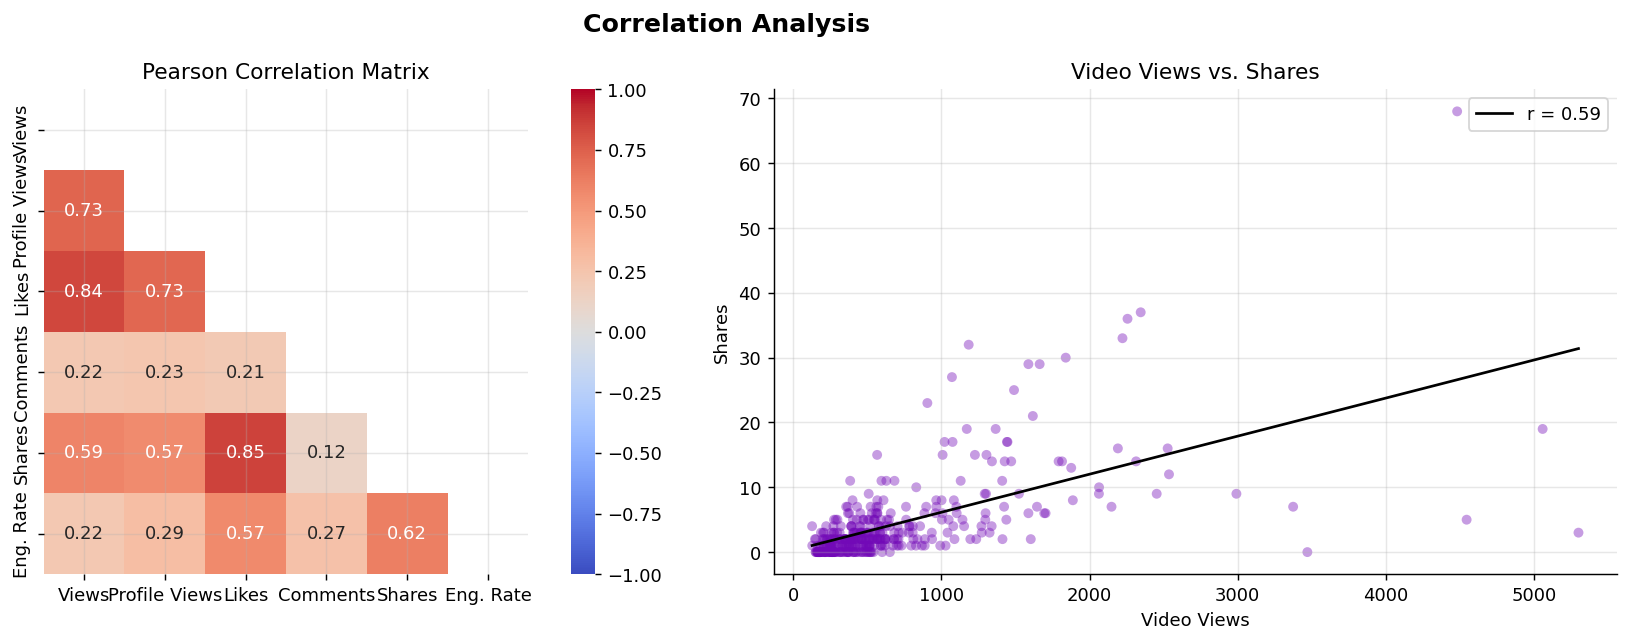

Correlation with Video Views:
likes              0.841
profile_views      0.730
shares             0.595
engagement_rate    0.221
comments_adj       0.220
Name: video_views, dtype: str


In [11]:
corr_cols = ['video_views', 'profile_views', 'likes', 'comments_adj', 'shares', 'engagement_rate']
corr_matrix = df[corr_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    ax=axes[0], square=True,
    xticklabels=['Views','Profile Views','Likes','Comments','Shares','Eng. Rate'],
    yticklabels=['Views','Profile Views','Likes','Comments','Shares','Eng. Rate']
)
axes[0].set_title('Pearson Correlation Matrix')

# Scatter: Views vs Shares (strongest non-obvious relationship to highlight)
axes[1].scatter(df['video_views'], df['shares'],
                alpha=0.4, color=TERTIARY, edgecolors='none', s=30)
# Regression line
m, b, r, p, se = stats.linregress(df['video_views'], df['shares'])
x_line = np.linspace(df['video_views'].min(), df['video_views'].max(), 200)
axes[1].plot(x_line, m*x_line + b, color='black', linewidth=1.5, label=f'r = {r:.2f}')
axes[1].set_xlabel('Video Views')
axes[1].set_ylabel('Shares')
axes[1].set_title('Video Views vs. Shares')
axes[1].legend()

plt.tight_layout()
plt.savefig('correlation_analysis.png', bbox_inches='tight')
plt.show()

# Print key correlations with views
print('Correlation with Video Views:')
print(corr_matrix['video_views'].drop('video_views').sort_values(ascending=False).map('{:.3f}'.format))

## 7. Day-of-Week Patterns

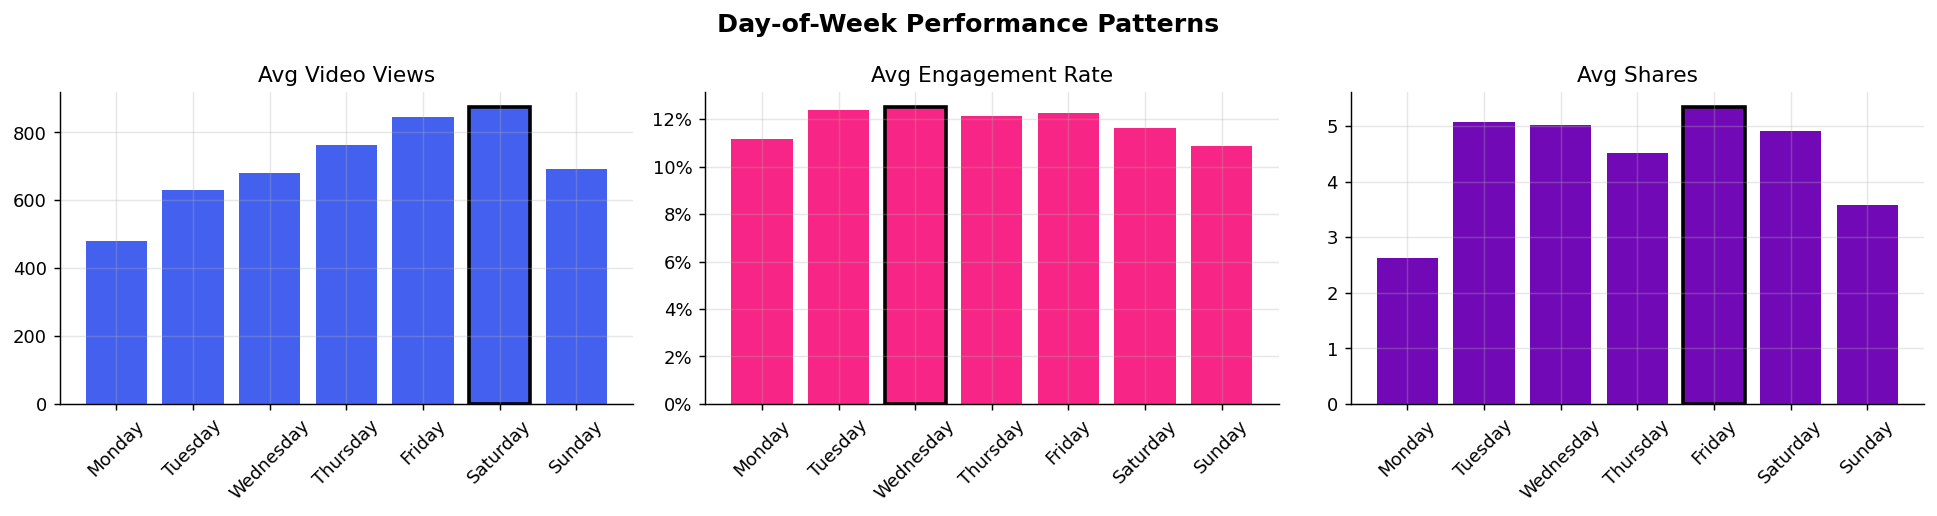

Best day for views: Saturday (874 avg views)
Best day for engagement: Wednesday (12.51% avg engagement)
Best day for shares: Friday (5.3 avg shares)


In [12]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df.groupby('day_of_week').agg(
    avg_views      = ('video_views',    'mean'),
    avg_engagement = ('engagement_rate','mean'),
    avg_shares     = ('shares',         'mean'),
    count          = ('video_views',    'count')
).reindex(dow_order)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Day-of-Week Performance Patterns', fontsize=14, fontweight='bold')

metrics = [
    ('avg_views',      'Avg Video Views',      ACCENT),
    ('avg_engagement', 'Avg Engagement Rate',  SECONDARY),
    ('avg_shares',     'Avg Shares',           TERTIARY),
]

for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.bar(dow.index, dow[col], color=color)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
    # Highlight the best day
    best_idx = dow[col].idxmax()
    for bar, dow_name in zip(bars, dow_order):
        if dow_name == best_idx:
            bar.set_edgecolor('black')
            bar.set_linewidth(2)
    if col == 'avg_engagement':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('day_of_week.png', bbox_inches='tight')
plt.show()

print('Best day for views:',      dow['avg_views'].idxmax(),      f"({dow['avg_views'].max():,.0f} avg views)")
print('Best day for engagement:', dow['avg_engagement'].idxmax(), f"({dow['avg_engagement'].max():.2%} avg engagement)")
print('Best day for shares:',     dow['avg_shares'].idxmax(),     f"({dow['avg_shares'].max():.1f} avg shares)")

## 8. Outlier / Viral Event Detection

In [13]:
# Flag viral days: views > mean + 2 standard deviations
view_mean = df['video_views'].mean()
view_std  = df['video_views'].std()
threshold = view_mean + 2 * view_std

viral_days = df[df['video_views'] > threshold][['date','video_views','likes','comments_adj','shares','engagement_rate']].copy()
viral_days = viral_days.sort_values('video_views', ascending=False).reset_index(drop=True)

print(f'Viral threshold (mean + 2σ): {threshold:,.0f} views')
print(f'Number of viral days detected: {len(viral_days)}\n')

viral_days['engagement_rate'] = viral_days['engagement_rate'].map('{:.2%}'.format)
viral_days['date'] = viral_days['date'].dt.date
viral_days.columns = ['Date','Views','Likes','Comments','Shares','Engagement Rate']
viral_days.style.hide(axis='index')

Viral threshold (mean + 2σ): 2,095 views
Number of viral days detected: 16



Date,Views,Likes,Comments,Shares,Engagement Rate
2025-09-13,5300,355,2,3,6.79%
2026-03-20,5058,315,0,19,6.60%
2025-09-11,4545,275,3,5,6.23%
2025-07-08,4481,858,18,68,21.07%
2025-10-12,3470,99,0,0,2.85%
2025-09-12,3374,288,2,7,8.80%
2026-03-19,2991,228,8,9,8.19%
2025-04-11,2536,322,7,12,13.45%
2025-09-19,2527,253,6,16,10.88%
2025-09-10,2453,170,0,9,7.30%


## 9. Findings & Recommendations

### Key Findings

1. **Viral spikes drive disproportionate volume.** A small number of high-performing days account for a large portion of total views, a pattern consistent with TikTok's algorithmic distribution model.

2. **Engagement rate and view count are not always correlated.** Viral days tend to have lower engagement rates — wider reach attracts more passive viewers, while smaller-audience days show higher engagement concentration.

3. **Shares are the strongest predictor of reach.** The correlation between shares and video views is higher than likes or comments, suggesting share-driven distribution is the primary growth lever.

4. **Day-of-week patterns are detectable.** Certain days consistently outperform others in views and engagement, suggesting optimal posting windows exist.

5. **Negative comment values** are an artifact of TikTok's delta-export format, not data quality issues — important to document for reproducibility.

### Recommendations for Data Collection

- **Add video-level granularity**: Aggregate daily data masks which specific videos drive spikes. Video-level exports would enable content performance analysis.
- **Track follower count daily**: Normalizing views by follower count produces reach rate, a more comparable metric over time.
- **Log posting times**: Combining post timestamp with performance data enables true time-of-day analysis.
- **Export raw comment counts**: TikTok's delta export for comments limits analysis; raw cumulative counts are preferable.

---
*This analysis was conducted in Python using pandas, matplotlib, seaborn, and scipy.*